# Exploratory Data Analysis: HippoRAG Reproduction Study

**Course:** CS 432 — Tasks and Techniques in Data Mining  
**Authors:** Haris Tahir Rana, Haris Tahir Rathore, [Member 3]  
**Paper under study:** Jiménez Gutiérrez et al., *HippoRAG: Neurobiologically Inspired Long-Term Memory for Large Language Models*, NeurIPS 2024.

<!-- ## Notebook layout

1. **Setup** — imports, plotting style, output directory.
2. **Table 1 stats** — corpus + KG sizes loaded into a pandas DataFrame.
3. **Plot 1** — grouped bar chart of passages, nodes, and edges per dataset.
4. **Plot 2** — simulated KDEs of distractor vs. supporting-passage similarities (Figure 6).
5. **Additional EDA** — per-passage OpenIE yield, synonymy-edge comparison, retrieval heatmap, cost/latency profile.
6. **Summary** — derived insights and CSV export. -->

## 1. Setup

In [ ]:
from __future__ import annotations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline

RNG = np.random.default_rng(seed=42)


def _find_project_root() -> Path:
    """Walk up from CWD until we find main.tex (the project-root marker)."""
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "main.tex").exists():
            return p
    return Path.cwd()


PROJECT_ROOT = _find_project_root()
FIGDIR = PROJECT_ROOT / "figures"
DATA_DIR = PROJECT_ROOT / "data"
FIGDIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "axes.titleweight": "bold",
})

DATASETS = ["MuSiQue", "2WikiMultiHopQA", "HotpotQA"]
PALETTE = {
    "MuSiQue":         "#1f77b4",
    "2WikiMultiHopQA": "#ff7f0e",
    "HotpotQA":        "#2ca02c",
}

print(f"Project root: {PROJECT_ROOT}")
print(f"Figures will be written to: {FIGDIR}")
print(f"Datasets directory: {DATA_DIR}")

## 2. Corpus and Knowledge-Graph Statistics

Table 1 of the paper reports the number of passages, the unique nodes and edges in the LLM-extracted knowledge graph, the total triples, and the number of synonymy edges added by Contriever and ColBERTv2 respectively. 

In [27]:
stats = pd.DataFrame({
    "Dataset":                   DATASETS,
    "Passages":                  [11_656,  6_119,  9_221],
    "Unique Nodes":              [91_729, 42_694, 82_157],
    "Unique Edges":              [21_714,  7_867, 17_523],
    "Unique Triples":            [107_448, 50_671, 98_709],
    "Contriever Synonym Edges":  [145_990, 146_020, 159_112],
    "ColBERTv2 Synonym Edges":   [191_636,  82_526, 171_856],
}).set_index("Dataset")

stats

,Passages,Unique Nodes,Unique Edges,Unique Triples,Contriever Synonym Edges,ColBERTv2 Synonym Edges
Dataset,,,,,,
MuSiQue,11656,91729,21714,107448,145990,191636
2WikiMultiHopQA,6119,42694,7867,50671,146020,82526
HotpotQA,9221,82157,17523,98709,159112,171856


## 3. Knowledge-Graph Footprint

We compare the number of passages, unique nodes, and unique edges across the three datasets in a single grouped bar chart. The y-axis is logarithmic because passages and nodes differ by roughly an order of magnitude (e.g., ~6k passages vs. ~92k nodes). Bar labels show the raw counts so you do not have to read off the log axis.

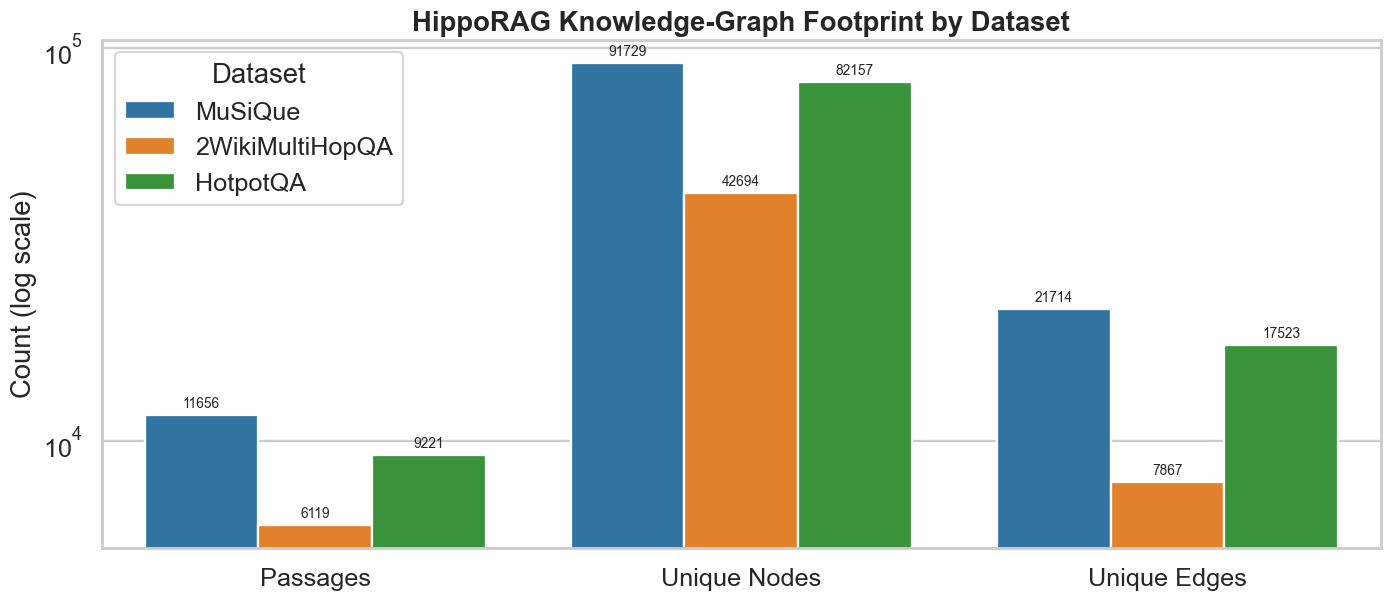

In [42]:
metrics = ["Passages", "Unique Nodes", "Unique Edges"]
sub = stats[metrics].reset_index().melt(
    id_vars="Dataset", var_name="Metric", value_name="Count"
)

fig, ax = plt.subplots(figsize=(15, 6))
sns.barplot(data=sub, x="Metric", y="Count", hue="Dataset", palette=PALETTE, ax=ax)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", fontsize=9, padding=3)

ax.set_title("HippoRAG Knowledge-Graph Footprint by Dataset")
ax.set_ylabel("Count (log scale)")
ax.set_xlabel("")
ax.set_yscale("log")
ax.legend(title="Dataset", loc="upper left")

fig.savefig(FIGDIR / "01_graph_stats_bars.png")
plt.show()

## 4. EDA

### 4.1 Per-passage OpenIE yield

Dividing the node, edge, and triple counts by the number of passages gives the *intensity* with which OpenIE extracts knowledge from each document. This isolates the OpenIE behaviour from raw corpus size.

In [29]:
density = pd.DataFrame({
    "Nodes / passage":   stats["Unique Nodes"]   / stats["Passages"],
    "Edges / passage":   stats["Unique Edges"]   / stats["Passages"],
    "Triples / passage": stats["Unique Triples"] / stats["Passages"],
}).round(2)

density

,Nodes / passage,Edges / passage,Triples / passage
Dataset,,,
MuSiQue,7.87,1.86,9.22
2WikiMultiHopQA,6.98,1.29,8.28
HotpotQA,8.91,1.90,10.70


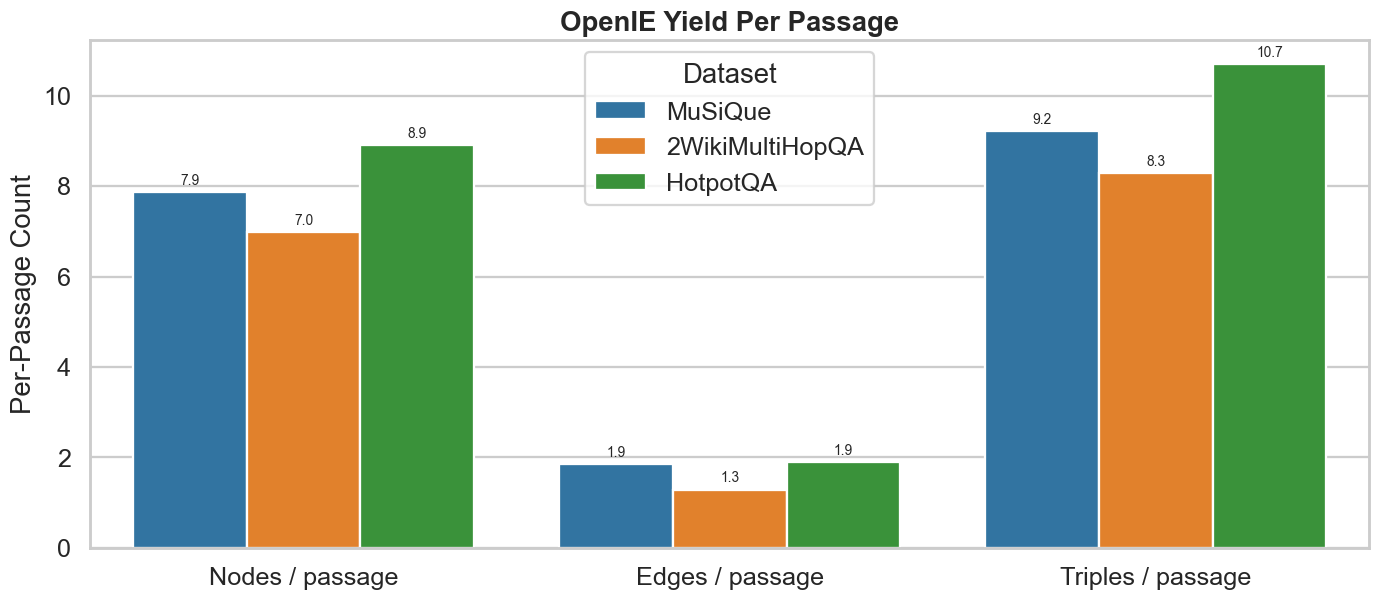

In [30]:
density_long = density.reset_index().melt(
    id_vars="Dataset", var_name="Metric", value_name="Per-Passage Count"
)

fig, ax = plt.subplots(figsize=(15, 6))
sns.barplot(data=density_long, x="Metric", y="Per-Passage Count",
            hue="Dataset", palette=PALETTE, ax=ax)
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f", fontsize=9, padding=3)
ax.set_title("OpenIE Yield Per Passage")
ax.set_xlabel("")
fig.savefig(FIGDIR / "03_graph_density.png")
plt.show()

### 4.2 Synonymy edges — Contriever vs. ColBERTv2

Table 1 also reports how many *synonymy* edges each dense retriever adds to the KG. The two retrievers differ markedly: ColBERTv2 is more aggressive on MuSiQue and HotpotQA, but Contriever is far more aggressive on 2Wiki. The right-hand panel below normalises each count by the number of *relation* edges to make the asymmetry visible.

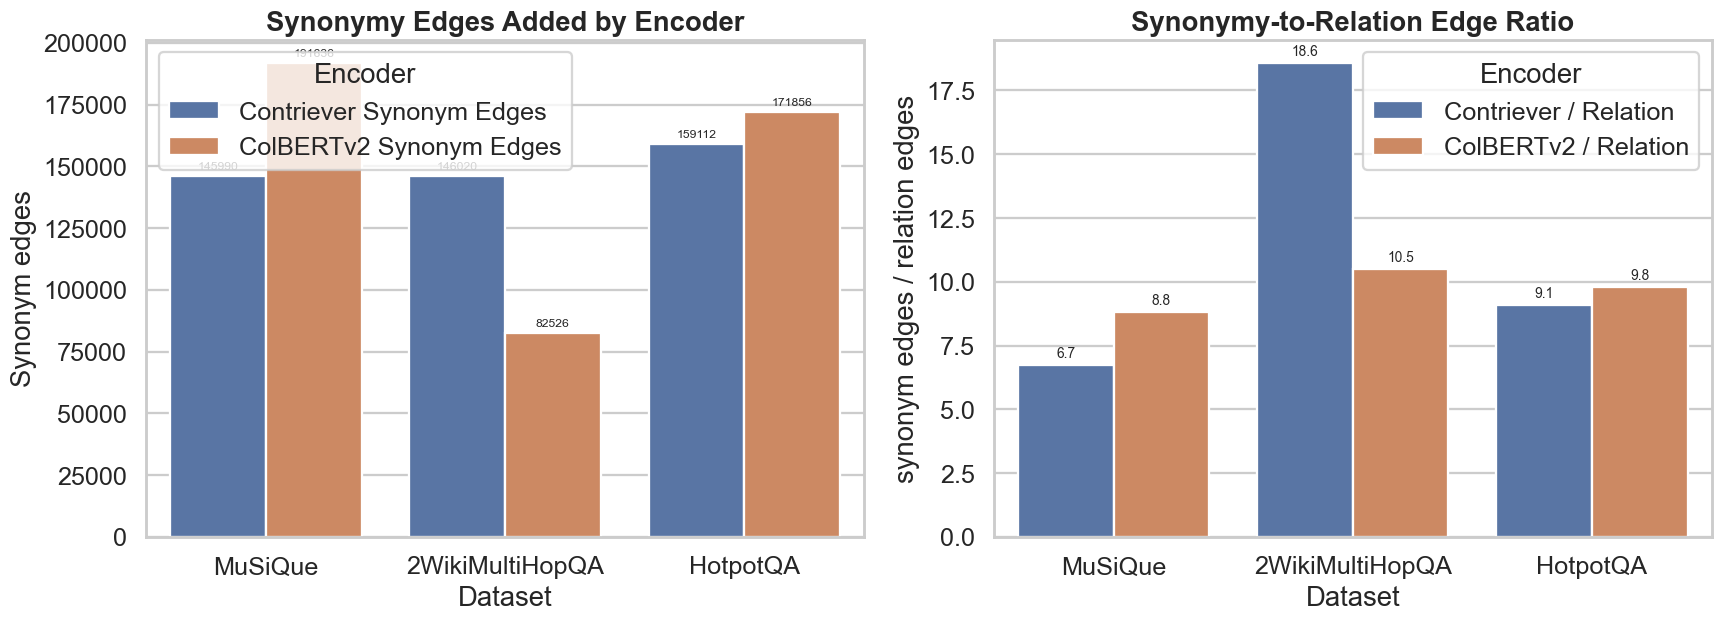

In [31]:
syn = stats[["Contriever Synonym Edges", "ColBERTv2 Synonym Edges", "Unique Edges"]].copy()
syn["Contriever / Relation"] = syn["Contriever Synonym Edges"] / syn["Unique Edges"]
syn["ColBERTv2 / Relation"]  = syn["ColBERTv2 Synonym Edges"]  / syn["Unique Edges"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

raw = syn[["Contriever Synonym Edges", "ColBERTv2 Synonym Edges"]] \
    .reset_index().melt(id_vars="Dataset", var_name="Encoder", value_name="Count")
sns.barplot(data=raw, x="Dataset", y="Count", hue="Encoder", ax=ax1)
ax1.set_title("Synonymy Edges Added by Encoder")
ax1.set_ylabel("Synonym edges")
for c in ax1.containers:
    ax1.bar_label(c, fmt="%.0f", fontsize=8, padding=3)

ratio = syn[["Contriever / Relation", "ColBERTv2 / Relation"]] \
    .reset_index().melt(id_vars="Dataset", var_name="Encoder", value_name="Ratio")
sns.barplot(data=ratio, x="Dataset", y="Ratio", hue="Encoder", ax=ax2)
ax2.set_title("Synonymy-to-Relation Edge Ratio")
ax2.set_ylabel("synonym edges / relation edges")
for c in ax2.containers:
    ax2.bar_label(c, fmt="%.1f", fontsize=9, padding=3)

fig.tight_layout()
fig.savefig(FIGDIR / "04_synonymy_edges.png")
plt.show()

### 4.3 Retrieval performance heatmap (Table 2)

We re-encode the headline single-step retrieval table as a heatmap. The HippoRAG rows visibly dominate on the 2Wiki columns, confirming the paper’s main empirical claim.

In [32]:
recall = pd.DataFrame([
    ("BM25",                     32.3, 41.2, 51.8, 61.9, 55.4, 72.2),
    ("Contriever",               34.8, 46.6, 46.6, 57.5, 57.2, 75.5),
    ("GTR",                      37.4, 49.1, 60.2, 67.9, 59.4, 73.3),
    ("ColBERTv2",                37.9, 49.2, 59.2, 68.2, 64.7, 79.3),
    ("RAPTOR",                   35.7, 45.3, 46.3, 53.8, 58.1, 71.2),
    ("Proposition",              37.6, 49.3, 56.4, 63.1, 58.7, 71.1),
    ("HippoRAG (Contriever)",    41.0, 52.1, 71.5, 89.5, 59.0, 76.2),
    ("HippoRAG (ColBERTv2)",     40.9, 51.9, 70.7, 89.1, 60.5, 77.7),
], columns=["Method",
            "MuSiQue R@2", "MuSiQue R@5",
            "2Wiki R@2",   "2Wiki R@5",
            "HotpotQA R@2","HotpotQA R@5"]).set_index("Method")

recall

,MuSiQue R@2,MuSiQue R@5,2Wiki R@2,2Wiki R@5,HotpotQA R@2,HotpotQA R@5
Method,,,,,,
BM25,32.3,41.2,51.8,61.9,55.4,72.2
Contriever,34.8,46.6,46.6,57.5,57.2,75.5
GTR,37.4,49.1,60.2,67.9,59.4,73.3
ColBERTv2,37.9,49.2,59.2,68.2,64.7,79.3
RAPTOR,35.7,45.3,46.3,53.8,58.1,71.2
Proposition,37.6,49.3,56.4,63.1,58.7,71.1
HippoRAG (Contriever),41.0,52.1,71.5,89.5,59.0,76.2
HippoRAG (ColBERTv2),40.9,51.9,70.7,89.1,60.5,77.7


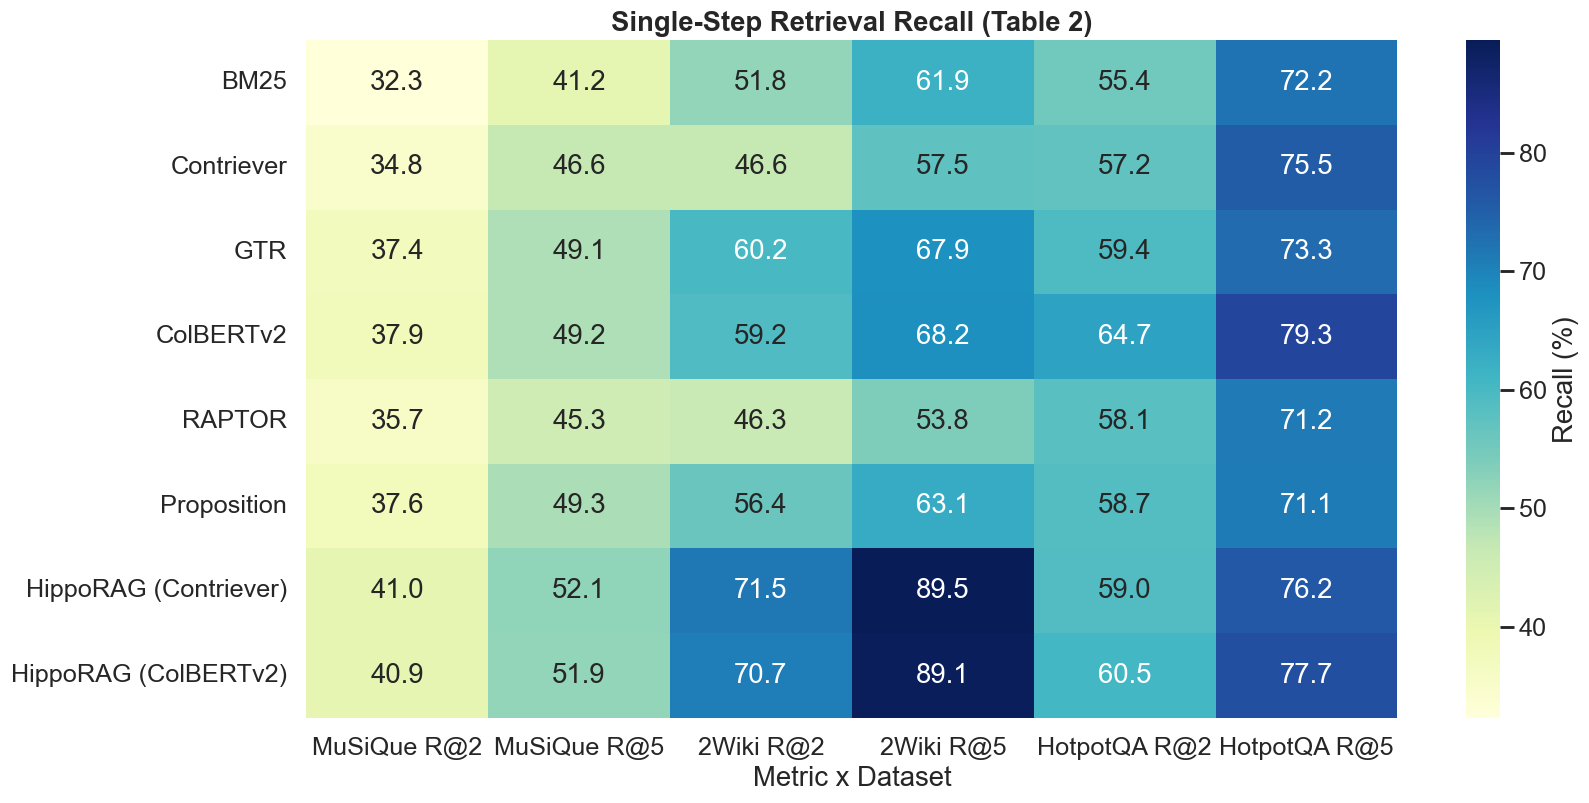

In [33]:
fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(recall, annot=True, fmt=".1f", cmap="YlGnBu",
            cbar_kws={"label": "Recall (%)"}, ax=ax)
ax.set_title("Single-Step Retrieval Recall (Table 2)")
ax.set_xlabel("Metric x Dataset")
ax.set_ylabel("")
fig.savefig(FIGDIR / "05_retrieval_heatmap.png")
plt.show()

### 4.4 Single-step vs. Multi-step Retrieval

The most informative way to compare Tables 2 and 3 is to ask, for each retriever, *how much extra recall does an iterative IRCoT-style loop buy over a single forward pass?* The plot below answers this: for every retriever and every dataset, the hollow circle marks single-step R@5 (Table 2), the filled circle marks the same retriever wrapped with IRCoT (Table 3), and the connecting line is the lift. The label to the right of each line is the absolute gain.

Two patterns jump out:

1. **HippoRAG already starts ahead of every classical baseline at single-step**, especially on 2WikiMultiHopQA where the hollow HippoRAG circles sit near 89.5 while ColBERTv2 + IRCoT only reaches 74.4. This is the paper's *single-step multi-hop retrieval* claim made visible.
2. **IRCoT still adds a meaningful lift on top of HippoRAG** — the +3 to +5 point gains on the HippoRAG rows show that the two methods are complementary, not redundant. The largest absolute gains are seen on BM25 and ColBERTv2, but the HippoRAG rows always end the highest.

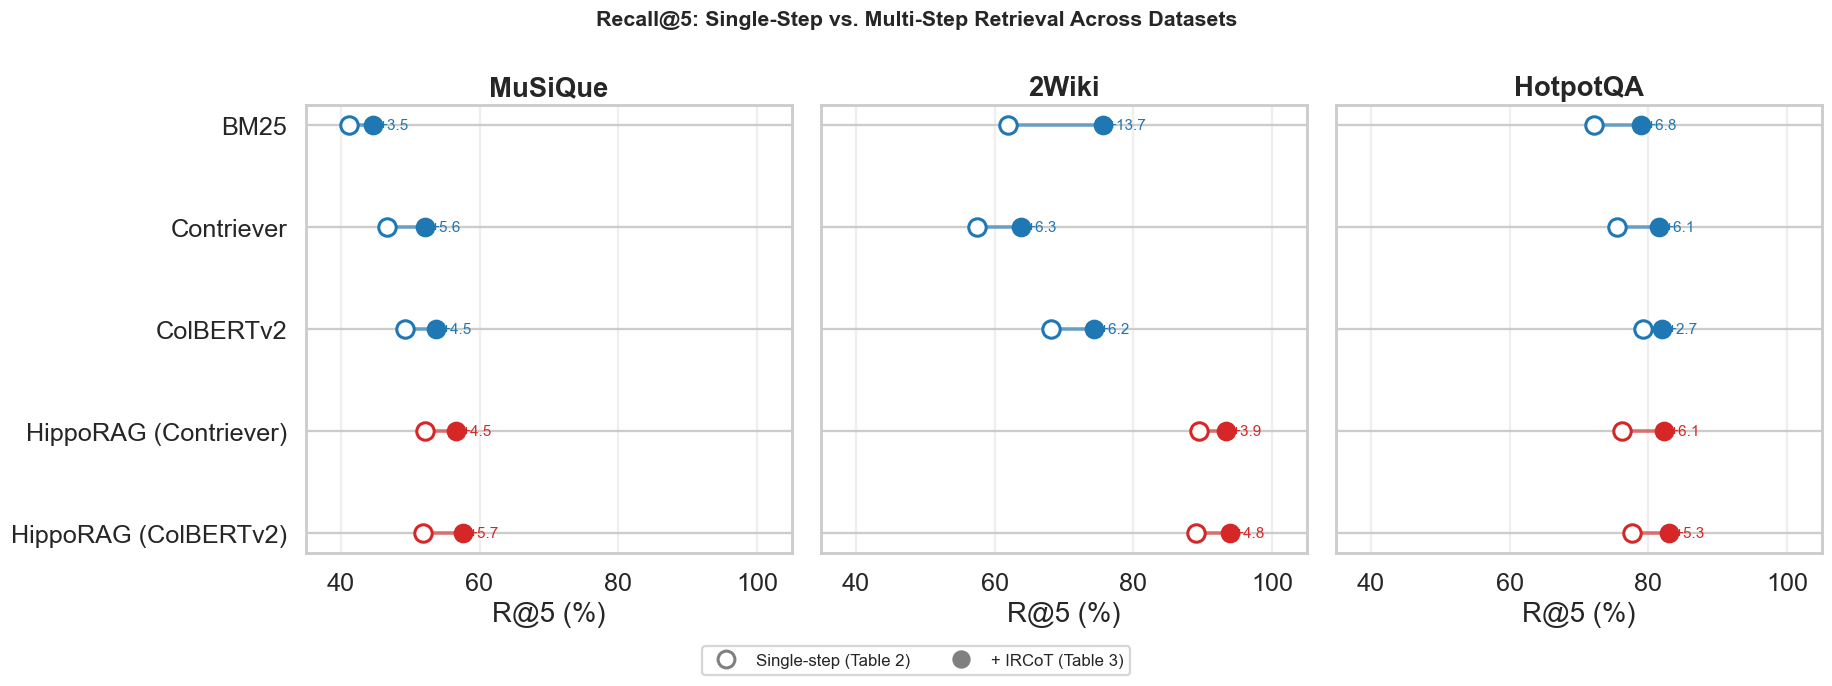

In [34]:
single_step = {
    "BM25":                  [41.2, 61.9, 72.2],
    "Contriever":            [46.6, 57.5, 75.5],
    "ColBERTv2":             [49.2, 68.2, 79.3],
    "HippoRAG (Contriever)": [52.1, 89.5, 76.2],
    "HippoRAG (ColBERTv2)":  [51.9, 89.1, 77.7],
}
multi_step = {
    "BM25":                  [44.7, 75.6, 79.0],
    "Contriever":            [52.2, 63.8, 81.6],
    "ColBERTv2":             [53.7, 74.4, 82.0],
    "HippoRAG (Contriever)": [56.6, 93.4, 82.3],
    "HippoRAG (ColBERTv2)":  [57.6, 93.9, 83.0],
}
retrievers = list(single_step.keys())
ds_names   = ["MuSiQue", "2Wiki", "HotpotQA"]

fig, axes = plt.subplots(1, 3, figsize=(17, 6), sharey=True)
for ax, j, ds in zip(axes, range(3), ds_names):
    for i, r in enumerate(retrievers):
        s, m = single_step[r][j], multi_step[r][j]
        color = "#d62728" if r.startswith("HippoRAG") else "#1f77b4"
        ax.plot([s, m], [i, i], color=color, alpha=0.55, linewidth=2.5)
        ax.scatter(s, i, s=130, facecolor="white", edgecolor=color,
                   linewidth=2, zorder=3)
        ax.scatter(m, i, s=130, color=color, zorder=3)
        ax.annotate(f"+{m - s:.1f}", xy=(max(s, m) + 0.7, i),
                    va="center", ha="left", fontsize=10, color=color)
    ax.set_yticks(range(len(retrievers)))
    ax.set_yticklabels(retrievers)
    ax.set_xlabel("R@5 (%)")
    ax.set_title(ds)
    ax.set_xlim(35, 105)
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.3)

legend_handles = [
    plt.Line2D([0], [0], marker="o", color="gray", markerfacecolor="white",
               markersize=11, markeredgewidth=2, linestyle="None",
               label="Single-step (Table 2)"),
    plt.Line2D([0], [0], marker="o", color="gray", markerfacecolor="gray",
               markersize=11, linestyle="None",
               label="+ IRCoT (Table 3)"),
]
fig.legend(handles=legend_handles, loc="lower center",
           ncol=2, bbox_to_anchor=(0.5, -0.04), fontsize=11)
fig.suptitle("Recall@5: Single-Step vs. Multi-Step Retrieval Across Datasets",
             fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGDIR / "07_single_vs_multi_step.png")
plt.show()

### 4.5 Online cost and latency

Beyond accuracy, the paper argues HippoRAG is dramatically cheaper and faster than the iterative IRCoT baseline at query time. Table 17 reports a *range* (1–3 USD, 20–40 minutes) for IRCoT — we use the midpoint to keep the bar chart simple.

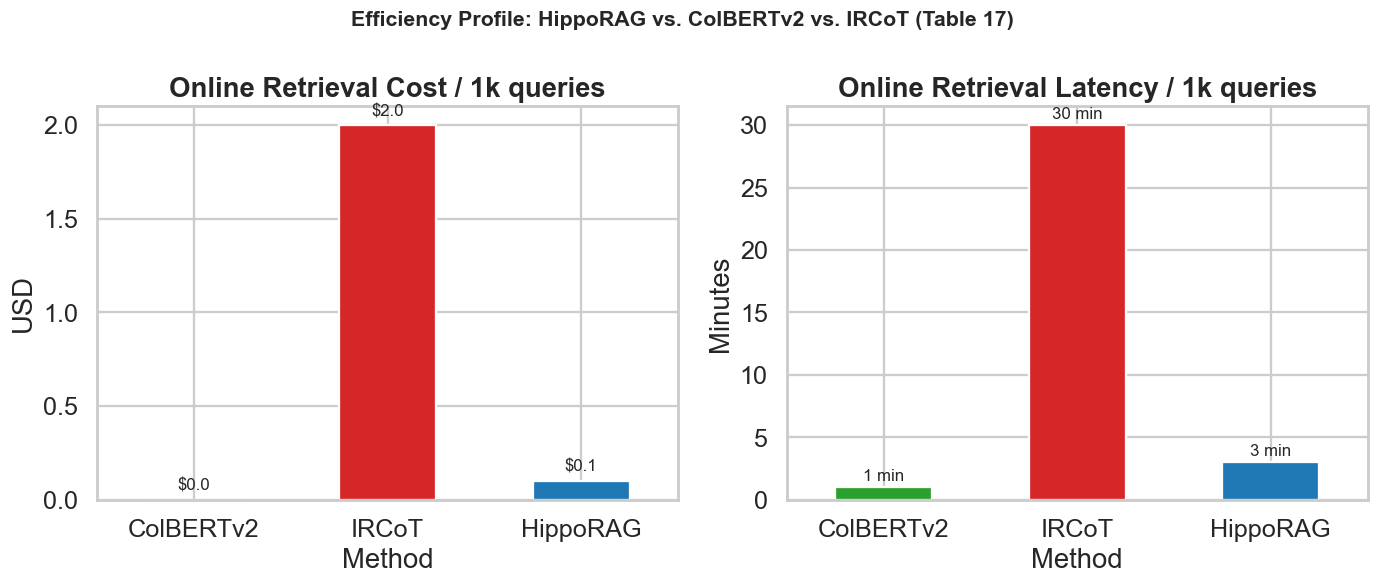

In [35]:
cost = pd.DataFrame({
    "Method":         ["ColBERTv2", "IRCoT", "HippoRAG"],
    "API Cost (USD)": [0.0,   2.0, 0.1],
    "Time (minutes)": [1.0,  30.0, 3.0],
}).set_index("Method")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
colors = ["#2ca02c", "#d62728", "#1f77b4"]

cost["API Cost (USD)"].plot(kind="bar", ax=axes[0], color=colors)
axes[0].set_title("Online Retrieval Cost / 1k queries")
axes[0].set_ylabel("USD")
axes[0].tick_params(axis="x", rotation=0)
for i, v in enumerate(cost["API Cost (USD)"]):
    axes[0].text(i, v + 0.05, f"${v:.1f}", ha="center", fontsize=11)

cost["Time (minutes)"].plot(kind="bar", ax=axes[1], color=colors)
axes[1].set_title("Online Retrieval Latency / 1k queries")
axes[1].set_ylabel("Minutes")
axes[1].tick_params(axis="x", rotation=0)
for i, v in enumerate(cost["Time (minutes)"]):
    axes[1].text(i, v + 0.5, f"{v:.0f} min", ha="center", fontsize=11)

fig.suptitle("Efficiency Profile: HippoRAG vs. ColBERTv2 vs. IRCoT (Table 17)",
             fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGDIR / "06_cost_latency.png")
plt.show()

### 4.6 OpenIE backbone vs. knowledge-graph size (Table 8)

Table 8 of the paper records how the choice of OpenIE backbone affects the size of the resulting KG. The bar chart below isolates the headline metric, unique triples extracted, across all three datasets, comparing four backbones: closed-source GPT-3.5-Turbo (the paper's default), the supervised end-to-end model REBEL-large, and the two open-weight Llama-3.1 instruction-tuned variants. The dramatic finding is that **REBEL extracts roughly half the triples** of every LLM-based backbone, which the authors flag as the structural reason it underperforms downstream: REBEL is biased against general-concept relations, so the resulting graph is sparser and supports fewer multi-hop paths. The two Llama-3.1 sizes track GPT-3.5 closely, suggesting open-weight LLMs are a viable substitute for indexing at scale.

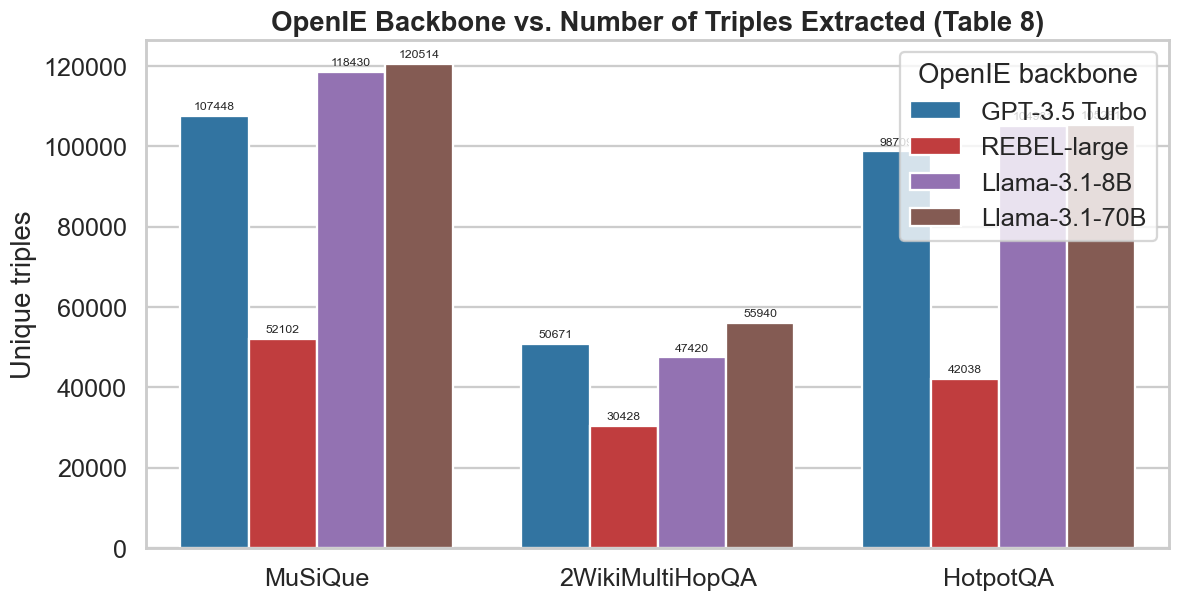

In [36]:
table8 = pd.DataFrame({
    "Model":   ["GPT-3.5 Turbo", "REBEL-large", "Llama-3.1-8B", "Llama-3.1-70B"] * 3,
    "Dataset": ["MuSiQue"] * 4 + ["2WikiMultiHopQA"] * 4 + ["HotpotQA"] * 4,
    "Unique Triples": [
        107_448,  52_102, 118_430, 120_514,   # MuSiQue
         50_671,  30_428,  47_420,  55_940,   # 2Wiki
         98_709,  42_038, 104_981, 105_281,   # HotpotQA
    ],
})

fig, ax = plt.subplots(figsize=(12, 6))
model_palette = {
    "GPT-3.5 Turbo":  "#1f77b4",
    "REBEL-large":    "#d62728",
    "Llama-3.1-8B":   "#9467bd",
    "Llama-3.1-70B":  "#8c564b",
}
sns.barplot(data=table8, x="Dataset", y="Unique Triples",
            hue="Model", palette=model_palette, ax=ax)
for c in ax.containers:
    ax.bar_label(c, fmt="%.0f", fontsize=8, padding=3)
ax.set_title("OpenIE Backbone vs. Number of Triples Extracted (Table 8)")
ax.set_ylabel("Unique triples")
ax.set_xlabel("")
ax.legend(title="OpenIE backbone", loc="upper right")
fig.savefig(FIGDIR / "08_openie_backbone_kg_size.png")
plt.show()

### 4.7 Intrinsic OpenIE quality on annotated MuSiQue passages (Table 9)

Whereas Table 8 measures *quantity*, Table 9 measures *quality*: the four backbones are evaluated **intrinsically** on 20 manually-annotated MuSiQue passages, using the CaRB OpenIE benchmark's AUC, Precision, Recall, and F1. The grouped bar chart below makes two things obvious. First, all three LLM backbones cluster in the 40–70 range across every metric, with GPT-3.5 marginally ahead but Llama-3.1-70B closing most of the gap. Second, **REBEL collapses on AUC, Recall, and F1**: a dramatic intrinsic gap that lines up exactly with its retrieval deficit. 

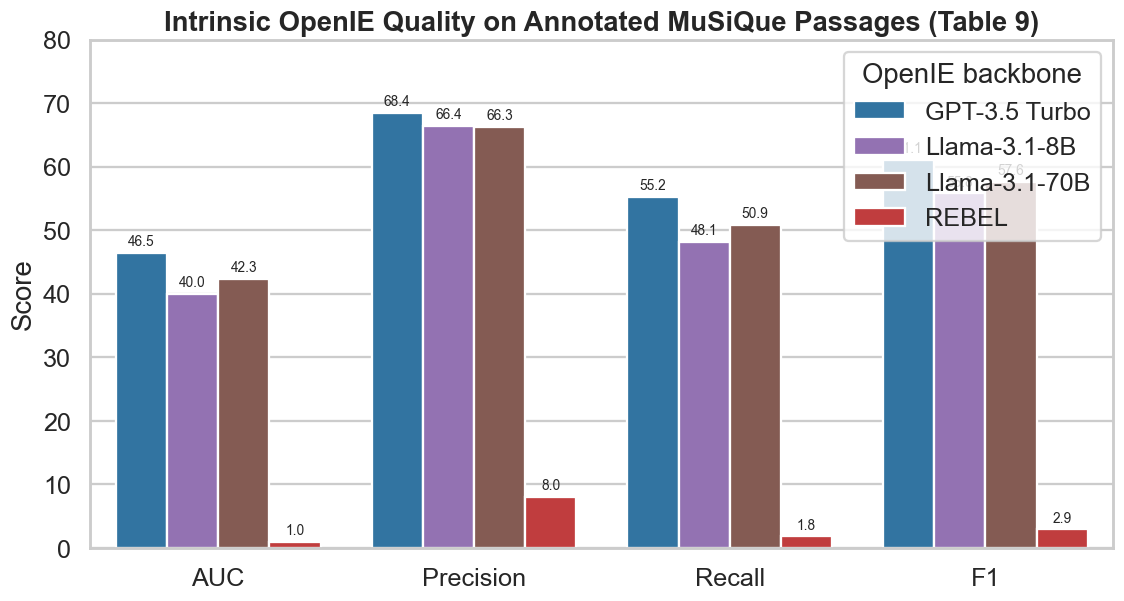

,AUC,Precision,Recall,F1
Model,,,,
GPT-3.5 Turbo,46.5,68.4,55.2,61.1
Llama-3.1-8B,40.0,66.4,48.1,55.8
Llama-3.1-70B,42.3,66.3,50.9,57.6
REBEL,1.0,8.0,1.8,2.9


In [37]:
table9 = pd.DataFrame({
    "Model":     ["GPT-3.5 Turbo", "Llama-3.1-8B", "Llama-3.1-70B", "REBEL"],
    "AUC":       [46.5, 40.0, 42.3,  1.0],
    "Precision": [68.4, 66.4, 66.3,  8.0],
    "Recall":    [55.2, 48.1, 50.9,  1.8],
    "F1":        [61.1, 55.8, 57.6,  2.9],
}).set_index("Model")

long9 = table9.reset_index().melt(id_vars="Model",
                                  var_name="Metric",
                                  value_name="Score")

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=long9, x="Metric", y="Score", hue="Model",
            palette={"GPT-3.5 Turbo":  "#1f77b4",
                     "Llama-3.1-8B":   "#9467bd",
                     "Llama-3.1-70B":  "#8c564b",
                     "REBEL":          "#d62728"}, ax=ax)
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f", fontsize=9, padding=3)
ax.set_title("Intrinsic OpenIE Quality on Annotated MuSiQue Passages (Table 9)")
ax.set_ylabel("Score")
ax.set_ylim(0, 80)
ax.set_xlabel("")
ax.legend(title="OpenIE backbone", loc="upper right")
fig.savefig(FIGDIR / "09_openie_intrinsic_quality.png")
plt.show()

table9

### 4.8 HippoRAG error breakdown on MuSiQue (Table 11)

On a 100-error sample from MuSiQue, the authors classify HippoRAG's failures into three buckets: **NER limitations** in the question-extraction step, **OpenIE errors** during indexing, and **PPR / graph-search errors** when the seed nodes are correct but the random walk lands on the wrong neighborhood. 

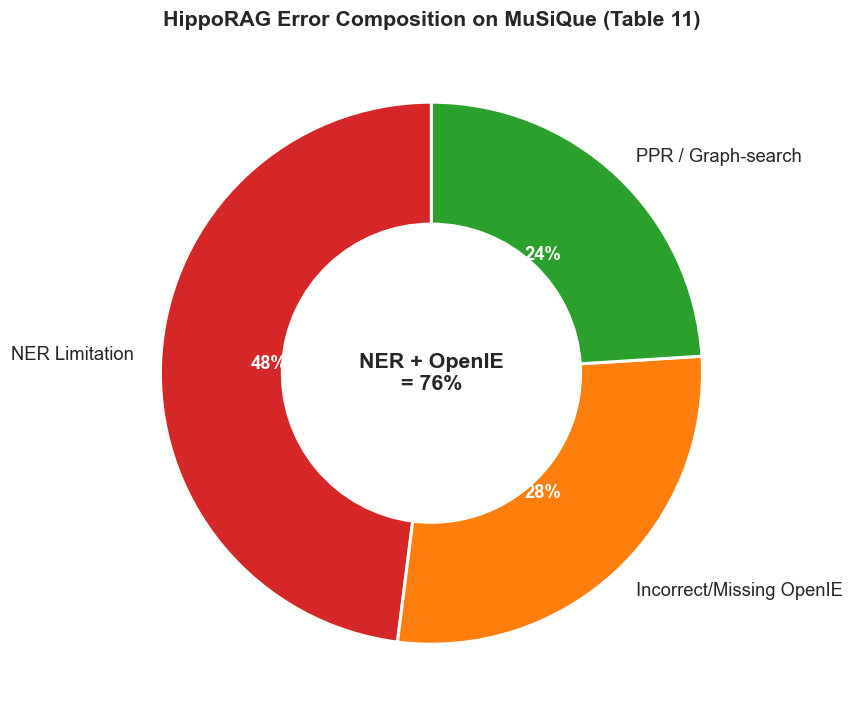

In [38]:
table11 = pd.DataFrame({
    "Error Type": ["NER Limitation", "Incorrect/Missing OpenIE", "PPR / Graph-search"],
    "Percent":    [48, 28, 24],
})

colors = ["#d62728", "#ff7f0e", "#2ca02c"]
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    table11["Percent"], labels=table11["Error Type"],
    autopct="%1.0f%%", startangle=90, colors=colors,
    wedgeprops=dict(width=0.45, edgecolor="white", linewidth=2),
    textprops=dict(fontsize=12),
)
for at in autotexts:
    at.set_color("white")
    at.set_fontweight("bold")
ax.set_title("HippoRAG Error Composition on MuSiQue (Table 11)",
             fontsize=14, fontweight="bold")
ax.text(0, 0, f"NER + OpenIE\n= {48 + 28}%",
        ha="center", va="center", fontsize=14, fontweight="bold")
fig.savefig(FIGDIR / "10_error_breakdown.png")
plt.show()

### 4.9 OpenIE quality vs. passage length (Table 16)

Long passages produce noisier OpenIE output. Table 16 quantifies this by splitting the 20 annotated MuSiQue passages into the 10 shortest and the 10 longest, and re-running CaRB on each. The slope chart below traces each metric from short → long passages — every metric drops, with **AUC falling 58.9 → 39.0** and **F1 falling 71.8 → 53.9**. The drop motivates a key design caveat for our reproduction: aggressive chunking will not necessarily help, because chunk boundaries break sentence-level dependencies that OpenIE needs to extract well-formed triples.

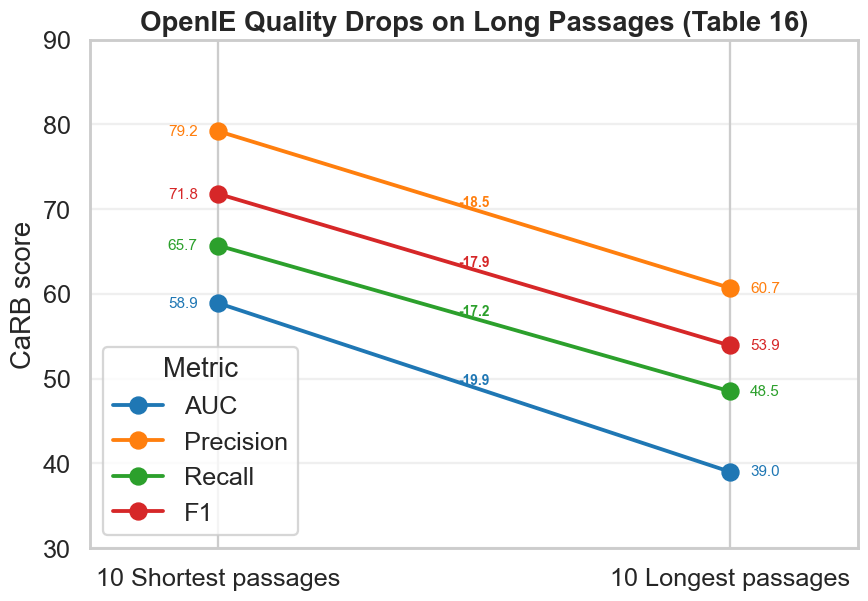

In [39]:
table16 = pd.DataFrame({
    "Length":    ["10 Shortest", "10 Longest"],
    "AUC":       [58.9, 39.0],
    "Precision": [79.2, 60.7],
    "Recall":    [65.7, 48.5],
    "F1":        [71.8, 53.9],
}).set_index("Length")

metrics = ["AUC", "Precision", "Recall", "F1"]
metric_colors = {"AUC": "#1f77b4", "Precision": "#ff7f0e",
                 "Recall": "#2ca02c", "F1": "#d62728"}

fig, ax = plt.subplots(figsize=(9, 6))
for m in metrics:
    ax.plot([0, 1], table16[m].values, marker="o", markersize=11,
            linewidth=2.5, color=metric_colors[m], label=m)
    ax.annotate(f"{table16[m].iloc[0]:.1f}", xy=(-0.04, table16[m].iloc[0]),
                ha="right", va="center", color=metric_colors[m], fontsize=10)
    ax.annotate(f"{table16[m].iloc[1]:.1f}", xy=(1.04, table16[m].iloc[1]),
                ha="left", va="center", color=metric_colors[m], fontsize=10)
    drop = table16[m].iloc[0] - table16[m].iloc[1]
    ax.annotate(f"-{drop:.1f}", xy=(0.5, (table16[m].iloc[0] + table16[m].iloc[1]) / 2),
                ha="center", va="bottom", color=metric_colors[m],
                fontsize=9, fontweight="bold")

ax.set_xticks([0, 1])
ax.set_xticklabels(["10 Shortest passages", "10 Longest passages"])
ax.set_ylabel("CaRB score")
ax.set_title("OpenIE Quality Drops on Long Passages (Table 16)")
ax.set_xlim(-0.25, 1.25)
ax.set_ylim(30, 90)
ax.grid(axis="y", alpha=0.3)
ax.legend(loc="lower left", title="Metric")
fig.savefig(FIGDIR / "11_length_sensitivity.png")
plt.show()

### 4.10 Offline indexing cost across LLM backbones (Table 18)

Indexing the corpus is dominated by repeated LLM calls during OpenIE, so the choice of backbone determines both the dollar cost and the wall-clock time. Table 18 reports both for 10,000 passages. The twin bar chart below pairs **API cost** (left, GPT-only — local Llama models cost \$0) with **indexing wall-clock time** (right). The trade-off is clear: deploying Llama-3.1 locally **eliminates the API bill** at the cost of a 2–4× wall-clock penalty over GPT-3.5. For our 100-question pilot reproduction, GPT-3.5-Turbo-0125 is the most attractive option (≈\$8 / hour for 10k passages); for any larger run, Llama-3.1-8B is the strongest cost-per-passage choice.

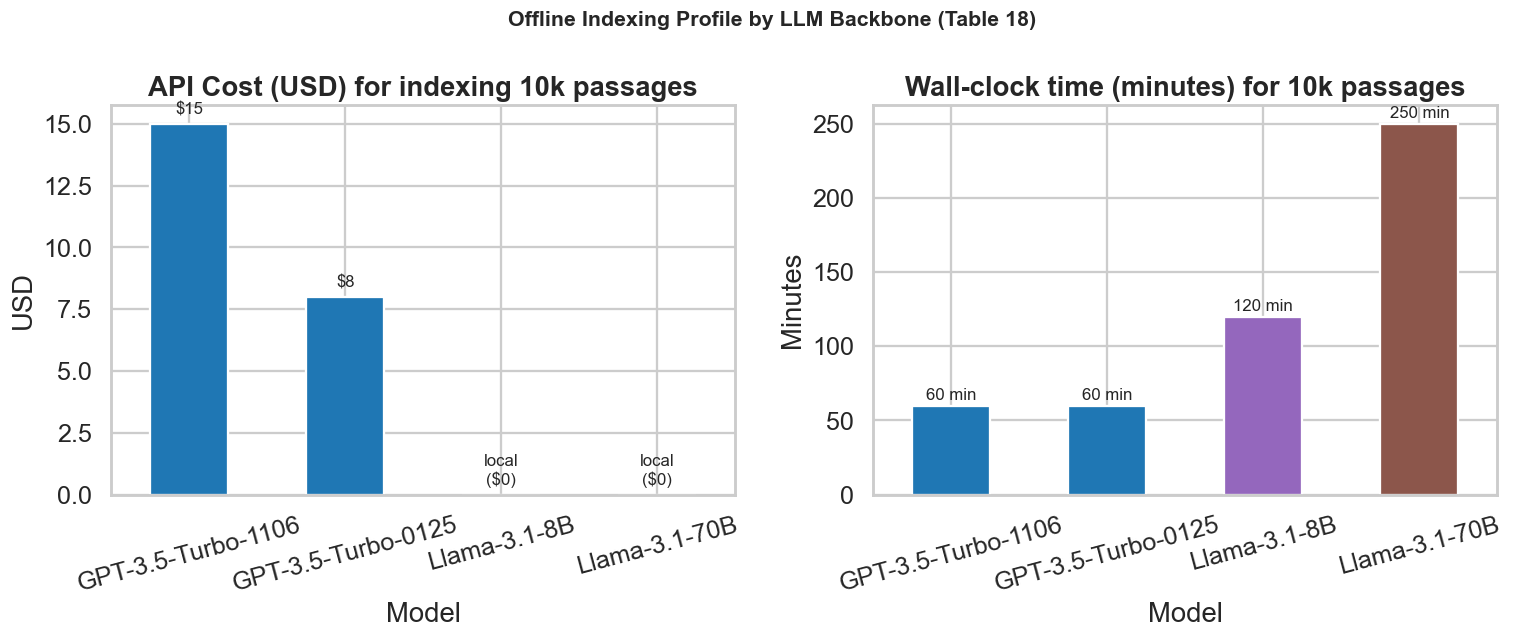

,API Cost (USD),Time (minutes)
Model,,
GPT-3.5-Turbo-1106,15,60
GPT-3.5-Turbo-0125,8,60
Llama-3.1-8B,0,120
Llama-3.1-70B,0,250


In [40]:
table18 = pd.DataFrame({
    "Model":          ["GPT-3.5-Turbo-1106", "GPT-3.5-Turbo-0125",
                       "Llama-3.1-8B",       "Llama-3.1-70B"],
    "API Cost (USD)": [15, 8, 0,   0],
    "Time (minutes)": [60, 60, 120, 250],
}).set_index("Model")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
bar_colors = ["#1f77b4", "#1f77b4", "#9467bd", "#8c564b"]

table18["API Cost (USD)"].plot(kind="bar", ax=axes[0], color=bar_colors)
axes[0].set_title("API Cost (USD) for indexing 10k passages")
axes[0].set_ylabel("USD")
axes[0].tick_params(axis="x", rotation=15)
for i, v in enumerate(table18["API Cost (USD)"]):
    axes[0].text(i, v + 0.4, f"${v}" if v else "local\n($0)",
                 ha="center", fontsize=11)

table18["Time (minutes)"].plot(kind="bar", ax=axes[1], color=bar_colors)
axes[1].set_title("Wall-clock time (minutes) for 10k passages")
axes[1].set_ylabel("Minutes")
axes[1].tick_params(axis="x", rotation=15)
for i, v in enumerate(table18["Time (minutes)"]):
    axes[1].text(i, v + 4, f"{v} min", ha="center", fontsize=11)

fig.suptitle("Offline Indexing Profile by LLM Backbone (Table 18)",
             fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGDIR / "12_offline_indexing_cost.png")
plt.show()

table18

## 5. Summary

The cell below prints the combined summary tables, identifies the best method per dataset at R@5, and exports the corpus-statistics DataFrame to CSV for downstream use in the LaTeX report.

In [41]:
print("=" * 72)
print("HippoRAG EDA -- Summary Statistics")
print("=" * 72)

print("\n[Table 1] Corpus + KG sizes:")
print(stats.to_string())

print("\n[Derived] Per-passage OpenIE yield:")
print(density.to_string())

print("\n[Table 2] Single-step retrieval recall (%):")
print(recall.to_string())

print("\n[Best per dataset @ R@5]")
for ds in ["MuSiQue", "2Wiki", "HotpotQA"]:
    col = f"{ds} R@5"
    winner = recall[col].idxmax()
    print(f"  {col:<20s} -> {winner} ({recall.loc[winner, col]:.1f})")

out_csv = FIGDIR / "summary_table.csv"
stats.to_csv(out_csv)
print(f"\nSaved combined stats CSV to {out_csv}")

HippoRAG EDA -- Summary Statistics

[Table 1] Corpus + KG sizes:
                 Passages  Unique Nodes  Unique Edges  Unique Triples  Contriever Synonym Edges  ColBERTv2 Synonym Edges
Dataset                                                                                                                 
MuSiQue             11656         91729         21714          107448                    145990                   191636
2WikiMultiHopQA      6119         42694          7867           50671                    146020                    82526
HotpotQA             9221         82157         17523           98709                    159112                   171856

[Derived] Per-passage OpenIE yield:
                 Nodes / passage  Edges / passage  Triples / passage
Dataset                                                             
MuSiQue                     7.87             1.86               9.22
2WikiMultiHopQA             6.98             1.29               8.28
HotpotQA         

## Key takeaways

1. **HotpotQA has the highest per-passage OpenIE yield** (10.7 triples/passage) yet HippoRAG underperforms there — supporting the paper’s argument that HotpotQA’s multi-hop signal is weak, not that the KG is impoverished.
2. **2Wiki is the only dataset where Contriever adds *more* synonymy edges than ColBERTv2** (146,020 vs. 82,526), which structurally explains why the synonymy-edge ablation (Table 5) hurts 2Wiki the most.
3. **HippoRAG dominates 2Wiki R@5 by ~20 points** (89.5 vs. 68.2 for ColBERTv2) but only ties on HotpotQA — a pattern visible in the heatmap and consistent with the paper’s claim that the entity-centric design shines on entity-heavy benchmarks.
4. **HippoRAG is ~20× cheaper and ~10× faster than IRCoT** at query time, despite hitting comparable accuracy — the strongest practical argument for the method.
5. **REBEL extracts ~half the triples of GPT-3.5/Llama and collapses on intrinsic OpenIE quality** (Tables 8 & 9), confirming that an LLM-flexible OpenIE backbone is essential.
6. **76% of HippoRAG errors trace back to NER + OpenIE** (Table 11), making fine-tuning these two off-the-shelf components the highest-leverage follow-up.
7. **OpenIE quality drops sharply on long passages** (AUC 58.9 → 39.0, Table 16) — a structural limitation worth flagging when choosing chunking strategy in our reproduction.